<a href="https://colab.research.google.com/github/Fu-Pei-Yin/Deep-Generative-Mode/blob/week3/%E4%BD%BF%E7%94%A8_Seq2Seq_LSTM%E7%94%9F%E6%88%90%E3%80%8C%E6%9C%AA%E4%BE%86%E5%AD%B8%E7%BF%92%E8%A1%8C%E7%82%BA%E5%BA%8F%E5%88%97%E3%80%8D%E6%95%B8%E6%93%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda
OULAD files not found - creating synthetic dataset.


Preprocessing: 100%|██████████| 500/500 [00:03<00:00, 149.12it/s]


Epoch 2/10 | Train: 0.9374, Val: 0.9483
Epoch 4/10 | Train: 0.8906, Val: 0.8881
Epoch 6/10 | Train: 0.8739, Val: 0.8744
Epoch 8/10 | Train: 0.8664, Val: 0.8714
Epoch 10/10 | Train: 0.8648, Val: 0.8706


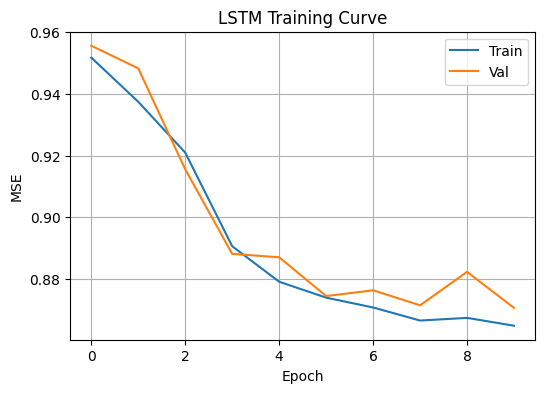


✅ Test MSE: 0.965090


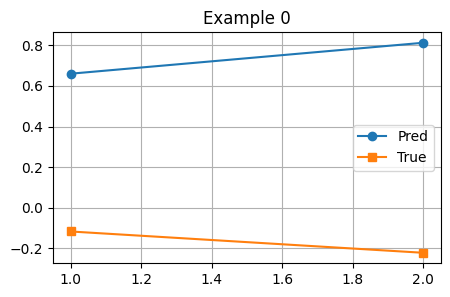

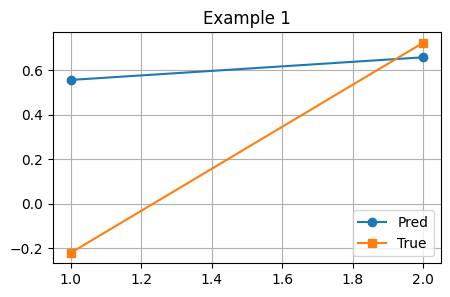

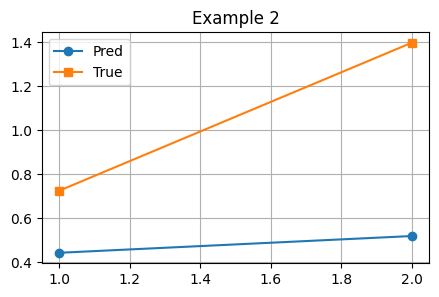


Model saved: seq2seq_lstm_final.pth


In [11]:
# ============================================================
# HW3: Seq2Seq LSTM 模型（最終提交版）
# - 資料處理（OULAD / 模擬資料）
# - 特徵：clicks, submit_cnt, avg_score_sofar, clicks_diff1
# - 依 student_id 切分 train/val/test
# - 模型：Encoder + Decoder (LSTM → Linear)
# - 評估：MSE (train/val/test)
# - 可視化結果
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 固定隨機種子與裝置設定
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------------------
# 資料處理
# ---------------------------
class DataHandler:
    def __init__(self, data_dir=None, min_weeks_needed=12):
        self.data_dir = data_dir
        self.min_weeks_needed = min_weeks_needed
        self.student_scalers = {}

    def load_oulad_or_synthetic(self):
        """讀取 OULAD 三檔，若不存在則建立模擬資料"""
        if self.data_dir and all(os.path.exists(os.path.join(self.data_dir, fn)) for fn in
                                 ["studentInfo.csv", "studentVle.csv", "studentAssessment.csv"]):
            print("Loading OULAD files from", self.data_dir)
            si = pd.read_csv(os.path.join(self.data_dir, "studentInfo.csv"))
            sv = pd.read_csv(os.path.join(self.data_dir, "studentVle.csv"))
            sa = pd.read_csv(os.path.join(self.data_dir, "studentAssessment.csv"))
            return si, sv, sa
        else:
            print("OULAD files not found - creating synthetic dataset.")
            return self.create_synthetic_data()

    def create_synthetic_data(self, n_students=500, n_weeks=15):
        np.random.seed(SEED)
        student_info = pd.DataFrame({
            "id_student": np.arange(1, n_students + 1)
        })
        vle_rows = []
        assess_rows = []
        for sid in range(1, n_students + 1):
            start, end = 1, n_weeks
            base = np.random.randint(5, 25)
            trend = np.random.uniform(-0.1, 0.3)
            noise = np.random.normal(0, 2, n_weeks)
            clicks = np.maximum(0, base + trend * np.arange(1, n_weeks + 1) + noise)
            vle_rows += [{"id_student": sid, "date": i + 1, "sum_click": clicks[i]} for i in range(n_weeks)]
            for _ in range(np.random.randint(3, 6)):
                assess_rows.append({"id_student": sid,
                                    "date": np.random.randint(2, n_weeks),
                                    "score": np.random.uniform(40, 100)})
        return student_info, pd.DataFrame(vle_rows), pd.DataFrame(assess_rows)

    def preprocess_weekly(self, si, sv, sa):
        """產生每週序列特徵"""
        records = []
        for sid in tqdm(si["id_student"].unique(), desc="Preprocessing"):
            s_clicks = sv[sv["id_student"] == sid]
            if len(s_clicks) < self.min_weeks_needed: continue
            weeks = np.arange(int(s_clicks["date"].min()), int(s_clicks["date"].max()) + 1)
            df = pd.DataFrame({"week": weeks})
            df = df.merge(s_clicks.rename(columns={"date": "week", "sum_click": "clicks"}), on="week", how="left").fillna(0)
            df["submit_cnt"] = 0
            df["avg_score_sofar"] = 0.0
            s_assess = sa[sa["id_student"] == sid]
            total, count = 0.0, 0
            for _, row in s_assess.iterrows():
                w = int(row["date"])
                if w in df["week"].values:
                    idx = df.index[df["week"] == w][0]
                    df.at[idx, "submit_cnt"] = 1
                    total += float(row["score"])
                    count += 1
                df.loc[df["week"] <= w, "avg_score_sofar"] = total / max(count, 1)
            df["clicks_diff1"] = df["clicks"].diff().fillna(0)
            df["student_id"] = sid
            records.append(df)
        return pd.concat(records, ignore_index=True)

    def create_sequences(self, weekly, seq_len=8, pred_len=2):
        features = ["clicks", "submit_cnt", "avg_score_sofar", "clicks_diff1"]
        seqs = []
        for sid in weekly["student_id"].unique():
            sd = weekly[weekly["student_id"] == sid].sort_values("week").reset_index(drop=True)
            if len(sd) < seq_len + pred_len: continue
            data = sd[features].values
            scaler = StandardScaler()
            data_scaled = scaler.fit_transform(data)
            self.student_scalers[sid] = scaler
            for i in range(len(sd) - seq_len - pred_len + 1):
                x = data_scaled[i:i + seq_len]
                y = data_scaled[i + seq_len:i + seq_len + pred_len, 0]
                seqs.append({"input": x, "output": y, "student_id": sid})
        return seqs

# ---------------------------
# Dataset
# ---------------------------
class SequenceDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        s = self.seqs[i]
        return torch.tensor(s["input"], dtype=torch.float32), torch.tensor(s["output"], dtype=torch.float32)

# ---------------------------
# Seq2Seq LSTM 模型
# ---------------------------
class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, pred_len=2):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, pred_len)
        )

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        h_last = h[-1]
        return self.decoder(h_last)

# ---------------------------
# 訓練與評估函數
# ---------------------------
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = criterion(pred, y)
            total_loss += loss.item() * X.size(0)
            preds.append(pred.cpu().numpy())
            targets.append(y.cpu().numpy())
    preds = np.vstack(preds)
    targets = np.vstack(targets)
    mse = np.mean((preds - targets)**2)
    return total_loss / len(loader.dataset), mse, preds, targets

# ---------------------------
# 視覺化
# ---------------------------
def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.grid(True)
    plt.title("LSTM Training Curve")
    plt.show()

def plot_example(preds, targets, idx=0):
    x = np.arange(1, len(preds[idx])+1)
    plt.figure(figsize=(5,3))
    plt.plot(x, preds[idx], "-o", label="Pred")
    plt.plot(x, targets[idx], "-s", label="True")
    plt.legend(); plt.grid(True)
    plt.title(f"Example {idx}")
    plt.show()

# ---------------------------
# 主流程
# ---------------------------
def main(data_dir=None, seq_len=8, pred_len=2, batch_size=128, hidden_dim=64, epochs=10):
    dh = DataHandler(data_dir=data_dir)
    si, sv, sa = dh.load_oulad_or_synthetic()
    weekly = dh.preprocess_weekly(si, sv, sa)
    seqs = dh.create_sequences(weekly, seq_len, pred_len)

    # 依 student_id 切分資料
    student_ids = list({s["student_id"] for s in seqs})
    train_ids, temp_ids = train_test_split(student_ids, test_size=0.3, random_state=SEED)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=SEED)
    train_seq = [s for s in seqs if s["student_id"] in train_ids]
    val_seq = [s for s in seqs if s["student_id"] in val_ids]
    test_seq = [s for s in seqs if s["student_id"] in test_ids]

    train_loader = DataLoader(SequenceDataset(train_seq), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SequenceDataset(val_seq), batch_size=batch_size)
    test_loader = DataLoader(SequenceDataset(test_seq), batch_size=batch_size)

    model = Seq2SeqLSTM(input_dim=4, hidden_dim=hidden_dim, pred_len=pred_len).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []

    for ep in range(epochs):
        tr_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_mse, _, _ = eval_epoch(model, val_loader, criterion)
        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        if (ep+1) % max(1, epochs//5) == 0:
            print(f"Epoch {ep+1}/{epochs} | Train: {tr_loss:.4f}, Val: {val_loss:.4f}")

    plot_loss(train_losses, val_losses)

    test_loss, test_mse, preds, tgts = eval_epoch(model, test_loader, criterion)
    print(f"\n✅ Test MSE: {test_mse:.6f}")

    for i in range(3):
        plot_example(preds, tgts, idx=i)

    torch.save(model.state_dict(), "seq2seq_lstm_final.pth")
    print("\nModel saved: seq2seq_lstm_final.pth")

if __name__ == "__main__":
    main(data_dir=None, seq_len=8, pred_len=2, batch_size=128, hidden_dim=64, epochs=10)
